In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.neighbors import NearestNeighbors
import gc

donwload the dataset

In [7]:
(train_dataset, test_dataset), dataset_info = tfds.load(
    name='caltech101:3.0.2',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True,
    data_dir="data",
    download=False
)

preprocess the data set sin preprocess_input, it is a function to normalize our images, for VGG19 is recomended use it

In [10]:
# Parámetros de procesamiento
base_dir = 'data/downloads/extracted/TAR_GZ.101_ObjectCategories.tar.gz/101_ObjectCategories'
target_size = (170, 170)  # Tamaño deseado para redimensionamiento

# Nombre de la carpeta a excluir
exclude_folder = 'BACKGROUND_Google'

# Inicialización de listas
images_list = []
labels_list = []

# Iterar sobre las carpetas (clases) en la carpeta base
for class_name in os.listdir(base_dir):
    if class_name == exclude_folder:
        continue  # Omitir la carpeta no deseada

    class_dir = os.path.join(base_dir, class_name)

    if os.path.isdir(class_dir):
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)

            try:
                # Leer la imagen usando PIL
                with Image.open(img_path) as img:
                    # Convertir imagen a RGB si no es RGB
                    if img.mode != 'RGB':
                        img = img.convert('RGB')

                    # Redimensionar imagen a un tamaño fijo usando LANCZOS
                    img_resized = img.resize(target_size, Image.LANCZOS)

                    # Convertir imagen a un array de NumPy
                    img_array = np.array(img_resized, dtype='float32')

                    # Asegurar que la imagen procesada tenga la forma correcta
                    if img_array.shape == (target_size[1], target_size[0], 3):  # (alto, ancho, canales)
                        images_list.append(img_array)
                        labels_list.append(class_name)
                    else:
                        print(
                            f"Imagen ignorada debido a dimensiones inconsistentes: {img_path}, tamaño: {img_array.shape}")

            except Exception as e:
                print(f"Error al procesar la imagen {img_path}: {e}")

# Convertir listas a arrays de NumPy
images_array = np.array(images_list)
labels_array = np.array(labels_list)

# Liberar memoria de las listas
del images_list
del labels_list
gc.collect()

print("Imágenes procesadas y clases almacenadas en memoria.")

# Normalizar imágenes con preprocess_input para VGG19
images_array = preprocess_input(images_array)

# Dividir en conjuntos de entrenamiento y prueba
train_imgs, test_imgs, train_labels, test_labels = train_test_split(
    images_array,  # Imágenes procesadas
    labels_array,  # Nombres de las clases
    test_size=0.3,  # 30% para prueba
    random_state=42,  # Para reproducibilidad
    stratify=labels_array,  # Asegura que la proporción de clases sea la misma en ambos conjuntos
    shuffle=True  # Barajar los datos antes de dividir
)

# Verificar el tamaño de los datos después de dividir
print(f"Tamaño del conjunto de entrenamiento: {train_imgs.shape}")
print(f"Tamaño del conjunto de prueba: {test_imgs.shape}")

# Liberar memoria de los arrays no utilizados
del images_array
del labels_array
gc.collect()

Imágenes procesadas y clases almacenadas en memoria.
Tamaño del conjunto de entrenamiento: (6073, 170, 170, 3)
Tamaño del conjunto de prueba: (2604, 170, 170, 3)


0

load the modelo VGG19

In [11]:
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(target_size[0], target_size[1], 3))
model = Model(inputs=base_model.input, outputs=base_model.layers[-1].output)

define function de extract features of the images

In [12]:
import gc

gc.collect()


160

In [13]:
def extract_features(images, model, batch_size=32):
    num_images = images.shape[0]
    feature_dim = np.prod(model.output_shape[1:])  # Tamaño total de características basado en la salida del modelo
    features = np.empty((num_images, feature_dim))  # Inicializar array para almacenar características

    # Obtener el número de procesadores disponibles
    num_workers = os.cpu_count() or 1  # Usar 1 si os.cpu_count() devuelve None

    def predict_batch(start, end):
        batch_images = images[start:end]
        batch_tensor = tf.convert_to_tensor(batch_images, dtype=tf.float32)
        feature_maps = model.predict(batch_tensor)

        # Aplanar las características si el modelo devuelve múltiples dimensiones
        batch_features = np.array([feature_map.flatten() for feature_map in feature_maps])
        return start, end, batch_features

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = []
        for start in range(0, num_images, batch_size):
            end = min(start + batch_size, num_images)
            futures.append(executor.submit(predict_batch, start, end))

        for future in as_completed(futures):
            start, end, batch_features = future.result()
            features[start:end] = batch_features

    return features


In [14]:
features_train = extract_features(train_imgs, model)

1/1 [==============================] - 24s 24s/step


1/1 [==============================] - 22s 22s/step


1/1 [==============================] - 11s 11s/step


In [25]:
print(f"Tamaño de las características extraídas: {features_train.shape}")

Tamaño de las características extraídas: (6073, 12800)


***retrieval***

In [26]:
num_neighbors = 10
nn_model = NearestNeighbors(n_neighbors=num_neighbors, algorithm='ball_tree').fit(features_train)


In [27]:
# Supongamos que test_imgs y test_labels son arrays de NumPy
num_samples = test_imgs.shape[0]  # Número total de muestras en test_imgs

# Selección aleatoria de un índice
random_index = np.random.randint(0, num_samples)

# Obtener la imagen y la etiqueta correspondiente
query_image = test_imgs[random_index]
label_query = test_labels[random_index]

print(f"Índice seleccionado: {random_index}")
print(f"Etiqueta de la imagen: {label_query}")

Índice seleccionado: 2334
Etiqueta de la imagen: laptop


In [28]:
query_image = test_imgs[1717]

we use a desnormalized function for plot or show the images

In [29]:
def desnormalized(img):
    mean = [103.939, 116.779, 123.68]  # Media para VGG19
    std = [1, 1, 1]  # Desviación estándar (simplificado para este ejemplo)

    # Deshacer la normalización
    img_denormalized = img * std + mean

    # Convertir de BGR a RGB (si es necesario)
    img_denormalized = img_denormalized[..., ::-1]

    # Asegurar que los valores estén entre 0 y 255
    img_denormalized = np.clip(img_denormalized, 0, 255).astype(np.uint8)
    return img_denormalized

process the query image for this runtime

In [30]:
query_desnormalized = desnormalized(query_image)
query_image = tf.expand_dims(query_image, axis=0)
query_desnormalized = tf.expand_dims(query_desnormalized, axis=0)

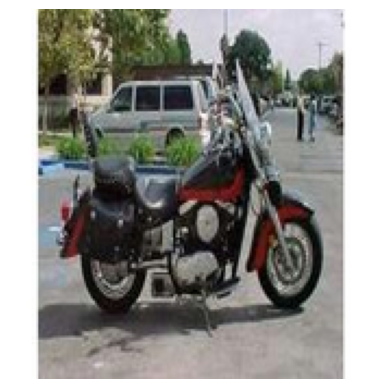

In [31]:
import matplotlib.pyplot as plt

plt.imshow(query_desnormalized[0])
plt.axis('off')
plt.show()

calculate the distances with neighboors

In [32]:
query_features = model.predict([query_image]).flatten().reshape(1, -1)

1/1 [==============================] - 0s 337ms/step


In [33]:
distances, indices = nn_model.kneighbors(query_features)
print("Indices of nearest neighbors:", indices)
print("Distances to nearest neighbors:", distances)

Indices of nearest neighbors: [[2429 1901 3726  990 4119  504 2310 5045 5909 5788]]
Distances to nearest neighbors: [[936.82692421 939.11310117 942.87214135 943.55364642 945.77356577
  952.92042532 958.48563529 973.93015083 978.5732009  979.9367985 ]]


In [34]:
# Ordenar distancias e índices en orden ascendente (más cercanos primero)
sorted_indices = np.argsort(distances[0])  # Ordena los índices basados en las distancias
sorted_distances = distances[0][sorted_indices]  # Ordena las distancias usando los índices
sorted_indices = indices[0][sorted_indices]  # Reorganiza los índices de vecinos usando los índices ordenados

print("Indices of nearest neighbors:", sorted_indices)
print("Distances to nearest neighbors:", sorted_distances)

Indices of nearest neighbors: [2429 1901 3726  990 4119  504 2310 5045 5909 5788]
Distances to nearest neighbors: [936.82692421 939.11310117 942.87214135 943.55364642 945.77356577
 952.92042532 958.48563529 973.93015083 978.5732009  979.9367985 ]


In [35]:
retrieved_images = []
retrieved_labels = []
for indice in sorted_indices.flatten():
    retrieved_images.append(desnormalized(train_imgs[indice]))
    retrieved_labels.append(train_labels[indice])


In [36]:
retrieved_labels

['Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes',
 'Motorbikes']

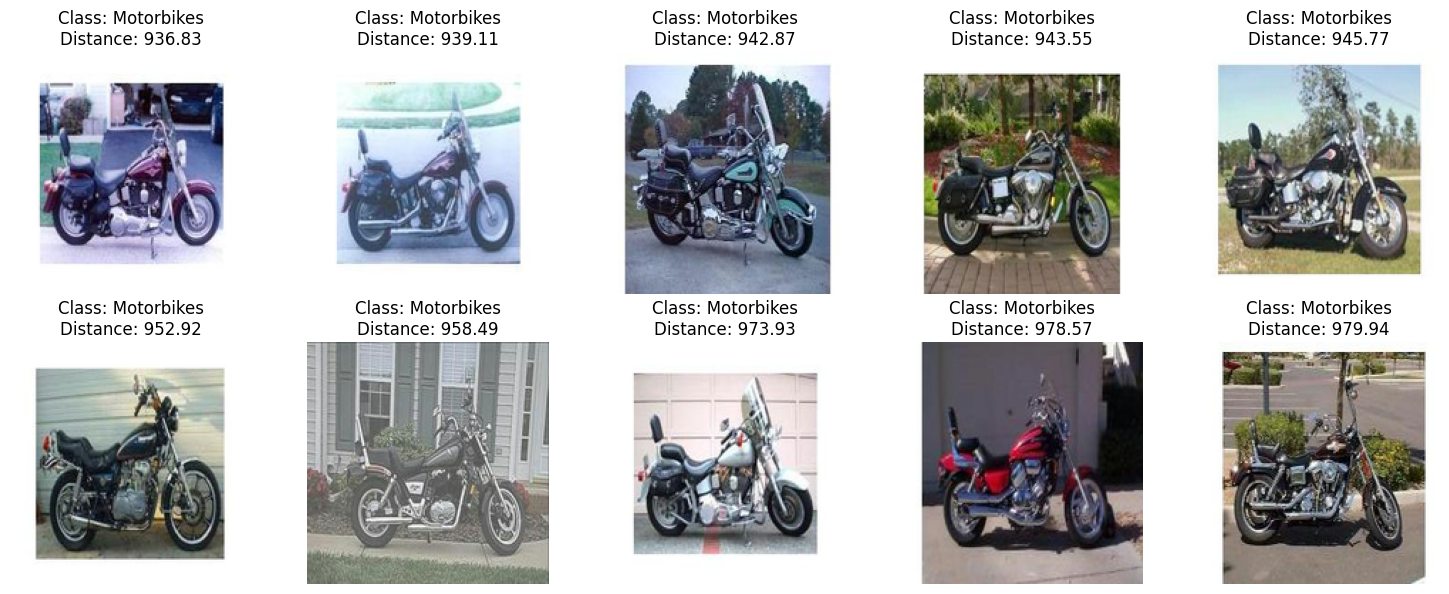

In [37]:

# Número de columnas deseadas
num_columns = 5

# Número de filas calculado en función del número total de imágenes
num_images = len(retrieved_images)
num_rows = int(np.ceil(num_images / num_columns))

# Crear la figura con la cuadrícula deseada
plt.figure(figsize=(num_columns * 3, num_rows * 3))

for i, image in enumerate(retrieved_images):
    row = i // num_columns
    col = i % num_columns
    plt.subplot(num_rows, num_columns, i + 1)
    plt.imshow(image)
    plt.title(f"Class: {retrieved_labels[i]}\nDistance: {round(distances[0][i], 2)}")
    plt.axis('off')

# Ajustar el espaciado para que no se superpongan
plt.tight_layout()
plt.show()

# Evaluate

In [39]:
def process_image(img):
    query_image = tf.expand_dims(img, axis=0)
    query_features = model.predict([query_image]).flatten().reshape(1, -1)
    distances, indices = nn_model.kneighbors(query_features)
    retrieved_labels = []
    for indice in indices.flatten():
        retrieved_labels.append(train_labels[indice])
    return retrieved_labels


In [41]:
relevant_labels = [label for label in train_labels if label == "Motorbikes"]
print(len(relevant_labels))

559


In [50]:
import time


def metrics(dataset, labels):
    start_time = time.time()  # Iniciar temporizador

    precision_scores = []
    recall_scores = []
    f1_scores = []  # Lista para almacenar los valores de F1-score

    for idx, img in enumerate(dataset):
        true_positives = 0
        false_positives = 0
        false_negatives = 0

        retrieved_labels = process_image(img)
        for retrieved_label in retrieved_labels:
            if retrieved_label == labels[idx]:
                true_positives += 1
            else:
                false_positives += 1

        relevant_labels = [label for label in train_labels if label == labels[idx]]
        false_negatives = len(relevant_labels) - true_positives

        precision = 0
        recall = 0
        f1_score = 0

        # Calcular precisión y recall
        if (true_positives + false_positives) > 0:
            precision = true_positives / (true_positives + false_positives)

        if (true_positives + false_negatives) > 0:
            recall = true_positives / (true_positives + false_negatives)

        # Calcular F1-score
        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)

        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1_score)  # Añadir el F1-score a la lista

    average_precision = sum(precision_scores) / len(precision_scores) if precision_scores else 0
    average_recall = sum(recall_scores) / len(recall_scores) if recall_scores else 0
    average_f1_score = sum(f1_scores) / len(f1_scores) if f1_scores else 0  # Calcular el promedio de F1-score

    end_time = time.time()  # Finalizar temporizador
    elapsed_time = end_time - start_time  # Calcular tiempo transcurrido

    print(f"Tiempo de ejecución: {elapsed_time:.2f} segundos")

    return average_precision, average_recall, average_f1_score, elapsed_time

In [51]:
average_precision, average_recall, average_f1score, elapsed_time = metrics(test_imgs, test_labels)

1/1 [==============================] - 0s 83ms/step
Tiempo de ejecución: 686.56 segundos


In [52]:
print(f"Average Precision: {average_precision}")
print(f"Average Recall: {average_recall}")
print(f"Average F1 Score: {average_f1score}")
print(f"Tiempo transcurrido: {elapsed_time:.2f} segundos")

Average Precision: 0.587250384024578
Average Recall: 0.07019918706285103
Average F1 Score: 0.11623250172306014
Tiempo transcurrido: 686.56 segundos


In [ ]:
# np.save('train_features_flat.npy', features_train)
# np.save('train_imgs_flat.npy', train_imgs)

In [34]:
# np.save('train_labels_flat.npy', train_labels)